# Overlay Histograms - Tortuosity

Generate histogram of tortuosity distribution based on the skeletonization results in Fiji

Input: Tortuosity and branch lenght column from the "05_VesselSkeleton.ipynb" notebook

Output: Histogram of tortuosity for all branches > 25 um


In [1]:
# 1. Import all required libraries
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import pandas as pd

## Define standard colors and legend titles

In [2]:
# Young mice without blood loss => shades of blue
Ycolors = ['lightblue', 'deepskyblue', 'dodgerblue', 'blue', 'navy']
Ylabels = ['VK-AA498', 'VK-AA499', 'VK-AA500', 'VK-AA501', 'VK-AA502']

# Young. blood loss mice => shades of orange
Bcolors = ['peachpuff', 'sandybrown', 'darkorange', 'chocolate', 'saddlebrown']
Blabels = ['VK-AA763', 'VK-AA764', 'VK-AA765', 'VK-AA766', 'VK-AA767']

# Old mice => shades of grey
Ocolors = ['black', 'dimgrey', 'grey', 'darkgrey', 'gainsboro']
Olabels = ['VK-AA758', 'VK-AA759', 'VK-AA760', 'VK-AA761', 'VK-AA762']

## Define datasets

In [3]:
# Young mice
Ymouse_1 = 'VK-AA498_shaft_2376-3055_skeleton_turt.txt'
Ymouse_2 = 'VK-AA499_shaft_2065-2655_skeleton_turt.txt'  
Ymouse_3 = 'VK-AA500_shaft_2506-3222_skeleton_turt.txt'
Ymouse_4 = 'VK-AA501_shaft_2376-3055_skeleton_turt.txt'
Ymouse_5 = 'VK-AA502_shaft_2341-3010_skeleton_turt.txt'

In [4]:
# Aged mice
Omouse_1 = 'VK-AA758_shaft_2740-3523_skeleton_turt.txt'
Omouse_2 = 'VK-AA759_shaft_2723-3501_skeleton_turt.txt'
Omouse_3 = 'VK-AA760_shaft_2866-3685_skeleton_turt.txt'
Omouse_4 = 'VK-AA761_shaft_2684-3451_skeleton_turt.txt'
Omouse_5 = 'VK-AA762_shaft_2905-3735_skeleton_turt.txt'

In [5]:
# Young, blood-loss mice
Bmouse_1 = 'VK-AA763_shaft_2142-2754_skeleton_turt.txt'
Bmouse_2 = 'VK-AA764_shaft_2271-2920_skeleton_turt.txt'
Bmouse_3 = 'VK-AA765_shaft_2205-2835_skeleton_turt.txt'
Bmouse_4 = 'VK-AA766_shaft_2096-2695_skeleton_turt.txt'
Bmouse_5 = 'VK-AA767_shaft_2166-2785_skeleton_turt.txt'

## Define function to plot the overlaid density distribution

In [6]:
# Define functions to read all five datasets of case and to generate overlaid histograms
def read_length_column(data: np.ndarray):    
    length =  np.genfromtxt(data ,skip_header=1, delimiter='\t', usecols=(0))      
    return length

def read_tortuosity_column(data: np.ndarray):
    tortuosity =  np.genfromtxt(data ,skip_header=1, delimiter='\t', usecols=(3))    
    return tortuosity

def plot_histograms(datasets, bins=80, colors=None, labels=None, title="Histogram", xlabel="Tortuosity", ylabel="Frequency", range=(1, 5)):
    plt.figure(figsize=(10, 6))
    
    for i, data in enumerate(datasets):
        # Plot histogram
        plt.hist(data, bins=bins, color=colors[i] if colors else None, label=labels[i] if labels else None, histtype='step', lw=2, density=True, range=range)
        
    # Add labels and title
    plt.xlabel(xlabel, fontsize = 14, fontweight = 'bold')
    plt.ylabel(ylabel, fontsize = 14, fontweight = 'bold')
    plt.title(title, fontsize = 16, fontweight = 'bold')

    # Add legend if labels are provided
    if labels:
        plt.legend()

    # Show the plot
    plt.show()
    
# Function to save the density histograms
def save_density_histograms_to_csv(datasets, bins=80, range=(1, 5), csv_filename="combined_density_histograms.csv"):
    
    # Create an empty list to store histogram dataframes
    dfs = []
    
    for i, data in enumerate(datasets):
        # Compute density histogram values
        values, bin_edges = np.histogram(data, bins=bins, range=range, density=False)
        
        # Create a DataFrame for the current dataset's histogram
        df = pd.DataFrame({'Bin Edges': bin_edges[:-1], f'Density Values_{i}': values})  # Add a column with density values for the current datasets
        
        # Append the DataFrame to the list
        dfs.append(df)
    
    # Merge all the individual dataframes on the 'Bin Edges' column
    merged_df = dfs[0]  # Start with the first DataFrame
    for df in dfs[1:]:
        merged_df = pd.merge(merged_df, df, on='Bin Edges', how='outer')
    
    # Save the merged DataFrame to the specified CSV file
    merged_df.to_csv(csv_filename, index=False)

## Young mice dataset

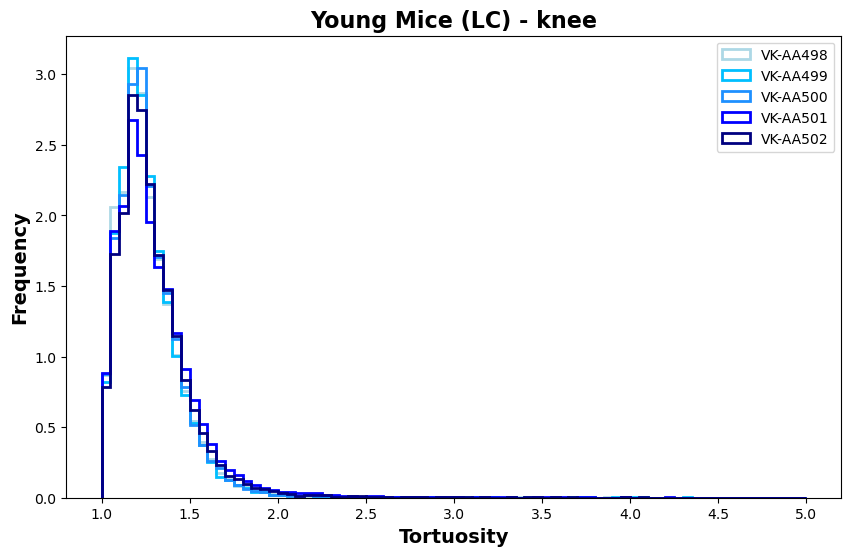

In [7]:
# Load young mice data sets
Ydatasets = [Ymouse_1, Ymouse_2, Ymouse_3, Ymouse_4, Ymouse_5]
Yall_length = list()

for dataset in Ydatasets:
    length = read_length_column(dataset)
    tortuosity = read_tortuosity_column(dataset)
    cleaned_tortuosity = np.where(length < 25, 0, tortuosity)
    Yall_length.append(cleaned_tortuosity)

plot_histograms(Yall_length, bins=80, colors=Ycolors, labels=Ylabels, title='Young Mice (LC) - knee')

## Young, blood loss mice dataset

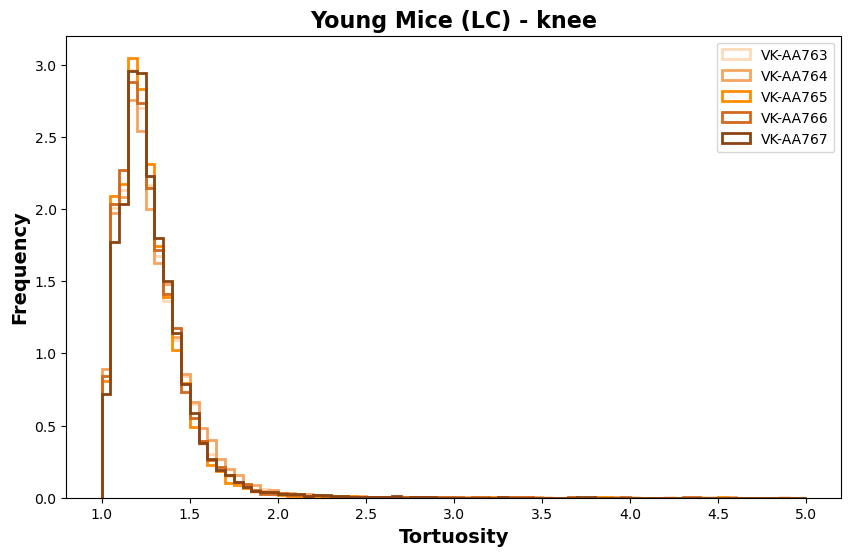

In [8]:
# Load young, blood loss mice data sets
Bdatasets = [Bmouse_1, Bmouse_2, Bmouse_3, Bmouse_4, Bmouse_5]
Ball_length = list()

for dataset in Bdatasets:
    length = read_length_column(dataset)
    tortuosity = read_tortuosity_column(dataset)
    cleaned_tortuosity = np.where(length < 25, 0, tortuosity)
    Ball_length.append(cleaned_tortuosity)

plot_histograms(Ball_length, bins=80, colors=Bcolors, labels=Blabels, title='Young Mice (LC) - knee')

## Aged mice

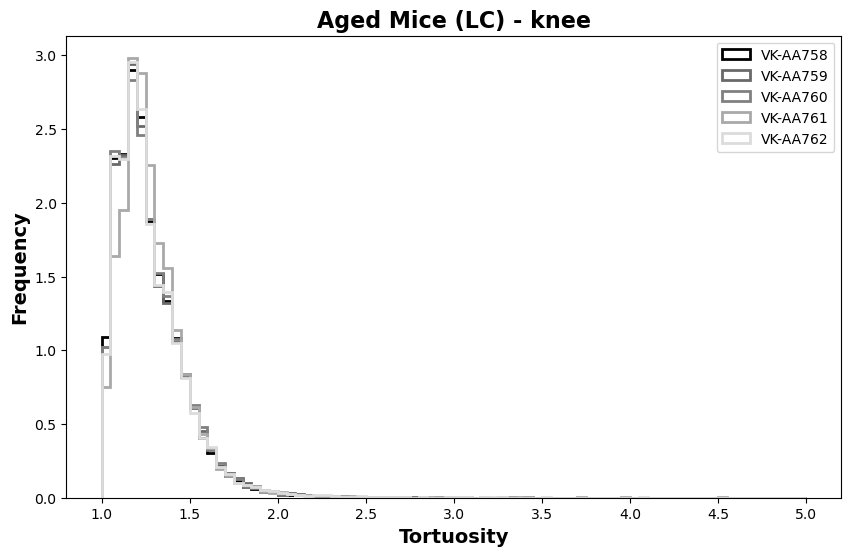

In [9]:
# Load young, blood loss mice data sets
Odatasets = [Omouse_1, Omouse_2, Omouse_3, Omouse_4, Omouse_5]
Oall_length = list()

for dataset in Odatasets:
    length = read_length_column(dataset)
    tortuosity = read_tortuosity_column(dataset)
    cleaned_tortuosity = np.where(length < 25, 0, tortuosity)
    Oall_length.append(cleaned_tortuosity)

plot_histograms(Oall_length, bins=80, colors=Ocolors, labels=Olabels, title='Aged Mice (LC) - knee')

## Save density histograms

In [10]:
save_density_histograms_to_csv(Ball_length, csv_filename="Blood-let(mid-knee2).csv")
save_density_histograms_to_csv(Yall_length, csv_filename="Young(mid-knee2).csv")
save_density_histograms_to_csv(Oall_length, csv_filename="Old(mid-knee2).csv")